# Single Slide Domain Detection Evaluation for SToFM with Classifier
This notebook is to evaluate the performance on single-slide domain detection, from the perspectives of prediction accuracy, spatial domain continuity, robustness and visualization.

Input: spatial coordinates, true layer, predicted layer

Use 3 slice to train a MLP on SToFM embeddings and evaluate with the 4th slice.




In [33]:
from calendar import day_abbr

import numpy as np
import pandas as pd
import scanpy as sc

# load data
data_folder = '../../../exploration/data/4_visium/'
adata = sc.read_h5ad(data_folder + '4_visium.h5ad')
adata = adata[np.logical_not(adata.obs['ground_truth'].isna())]  #remove NAN
pred_label = pd.read_csv(data_folder + '4_visium_stofm_classification_domain_detection.csv').to_numpy()
adata.obs['pred_domain'] = pred_label
adata.obs['pred_domain'] = pd.Categorical(adata.obs['pred_domain'])
print(adata)
print(adata.obs.ground_truth.unique())
print(adata.obs.pred_domain.unique())

AnnData object with n_obs × n_vars = 4595 × 33538
    obs: 'in_tissue', 'array_row', 'array_col', 'Region', 'ground_truth', 'pred_domain'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatial'
    obsm: 'spatial'
['Layer1', 'Layer5', 'Layer3', 'Layer4', 'Layer6', 'WM', 'Layer2']
Categories (7, object): ['Layer1', 'Layer2', 'Layer3', 'Layer4', 'Layer5', 'Layer6', 'WM']
[1, 5, 0, 2, 4, 6, 3]
Categories (7, int64): [0, 1, 2, 3, 4, 5, 6]


/var/folders/cb/yd_h3b5576d6wq5rydwp3_kr0000gn/T/ipykernel_61965/2805727180.py:12: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs['pred_domain'] = pred_label


## 1. Prediction Accuracy

In [34]:
from evaluation_utils import STFMEvaluation

eval = STFMEvaluation()
metrics = eval.compute_prediction_accuracy(adata.obs.ground_truth, adata.obs.pred_domain)

metrics.to_csv(data_folder + 'accuracy.csv', sep=',')
print(metrics)

ARI          0.473676
NMI          0.481902
HOM          0.474724
COM          0.489301
V_Measure    0.481902
dtype: float64


## 2. Spatial Domain Continuity

In [35]:
domain_continuity_metrics = eval.compute_domain_continuity(
    spatial_coordinates=pd.concat([adata.obs.array_row, adata.obs.array_col], axis=1),
    labels_pred=adata.obs.pred_domain)

domain_continuity_metrics.to_csv(data_folder + 'continuity.csv', sep=',')
print(domain_continuity_metrics)

ASW     -0.074421
CHAOS    0.062106
PAS      0.276387
dtype: float64


## 3. Visualization


#### a. Histology

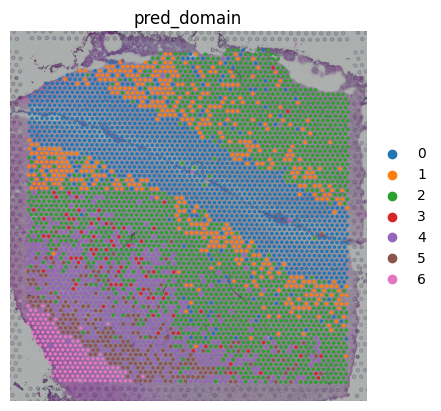

In [37]:
from evaluation_utils import STFMEvaluation

# prediction
eval = STFMEvaluation()
eval.plot_spatial_domains(adata, domain_col='pred_domain', use_histology=True, slice_id='151510',
                          save=data_folder + 'pred_spatial_domains.png')

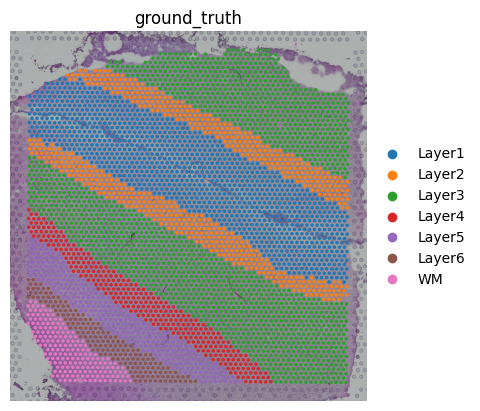

In [38]:
# ground truth
eval.plot_spatial_domains(adata, domain_col='ground_truth', use_histology=True, slice_id='151510',
                          save=data_folder + 'ground_truth_spatial_domains.png')

#### b. UMAP

/Users/sheryli/opt/anaconda3/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


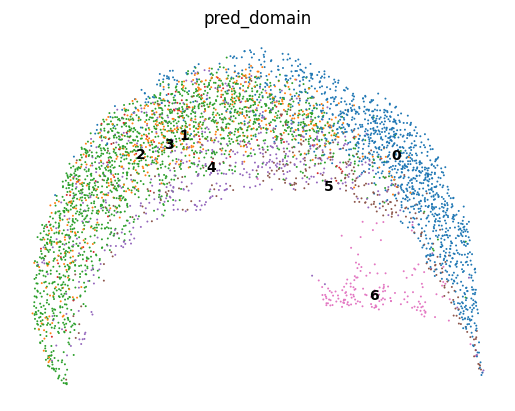

In [39]:
# prediction
eval.plot_embedding_domains(adata, domain_col='pred_domain', basis='umap', compute_if_missing=True,
                            save=data_folder + 'pred_emb_umap.png')

/Users/sheryli/opt/anaconda3/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


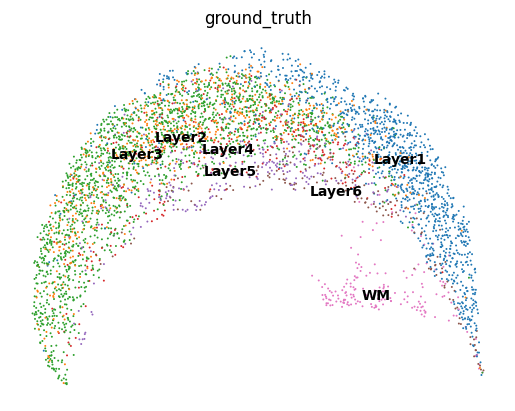

In [42]:
# ground truth
eval.plot_embedding_domains(adata, domain_col='ground_truth', basis='umap', compute_if_missing=True,
                            save=data_folder + 'ground_truth_emb_domains.png')